In [1]:
# -*- coding: utf-8 -*-

import os
import re
import json
import requests
import trafilatura
from datasets import Dataset
from transformers import pipeline, AutoTokenizer
import matplotlib.pyplot as plt
import nltk

nltk.download("punkt")

# ============================================
# ПАРАМЕТРЫ ВАРИАНТА
# ============================================

VARIANT = 17
TOPIC = "Sentiment Analysis"
MODEL_NAME = "cointegrated/rubert-tiny-sentiment-balanced"
TOKEN_SIZE = 512

SOURCES = ["habr.com", "wikipedia.org", "huggingface.co"]

# ============================================
# ЗАГРУЗКА МОДЕЛИ И ТОКЕНИЗАТОРА
# ============================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

classifier = pipeline(
    "text-classification",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME
)

print(f"Модель анализа тональности: {MODEL_NAME}")

/home/virile/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/virile/.local/lib/python3.10/site-packages/nltk/downloader.py:980: RuntimeWarning: Security Violation [pathsec.urlopen]: SSRF attempt to restricted IP 198.18.0.67
  ElementTree.parse(urlopen(self._url)).getroot()
[nltk_data] Downloading package punkt to /home/virile/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Loading weights: 100%|██████████| 57/57 [00:00<00:00, 2569.29it/s]
BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny-sentiment-balanced
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

Модель анализа тональности: cointegrated/rubert-tiny-sentiment-balanced


In [2]:
# ============================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================

def fetch_article_text(url):
    try:
        downloaded = trafilatura.fetch_url(url)
        if downloaded:
            text = trafilatura.extract(downloaded)
            return text
        return None
    except Exception as e:
        print(f"Ошибка при получении {url}: {e}")
        return None


def clean_text(text):
    if not text:
        return ""
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^а-яА-Яa-zA-Z0-9.,!?;:()%\-\s]", "", text)
    text = re.sub(r"([.,!?;:])\1+", r"\1", text)
    return text.strip()


def chunk_text_by_tokens(text, token_size=512):
    """Разбивает текст на чанки ровно по token_size токенов.
    Каждый чанк — это список из token_size token ID.
    Последний чанк дополняется pad-токенами до token_size."""
    all_ids = tokenizer.encode(text, add_special_tokens=False)
    chunks = []
    for i in range(0, len(all_ids), token_size):
        chunk_ids = all_ids[i:i + token_size]
        # дополняем последний чанк до token_size
        if len(chunk_ids) < token_size:
            chunk_ids = chunk_ids + [tokenizer.pad_token_id] * (token_size - len(chunk_ids))
        chunks.append(chunk_ids)
    return chunks

In [3]:
# ============================================
# ИСТОЧНИКИ И СБОР ТЕКСТОВ
# ============================================

predefined_urls_by_source = {
    "habr.com": [
        "https://habr.com/ru/companies/otus/articles/724234/",
        "https://habr.com/ru/articles/881998/"
    ],
    "wikipedia.org": [
        "https://en.wikipedia.org/wiki/Sentiment_analysis",
        "https://en.wikipedia.org/wiki/Emotion_classification"
    ],
    "huggingface.co": [
        "https://huggingface.co/tasks/text-classification",
        "https://huggingface.co/docs/transformers/en/tasks/sequence_classification"
    ]
}

all_texts = []
fetched_urls = []

print("Получение статей из заданных URL...")

for source_domain in SOURCES:
    urls_for_domain = predefined_urls_by_source.get(source_domain, [])
    for url in urls_for_domain:
        print(f"Пытаюсь получить: {url}")
        article_text = fetch_article_text(url)
        if article_text:
            all_texts.append(article_text)
            fetched_urls.append(url)
            print(f"Успешно получен текст: {url}")
        else:
            print(f"Не удалось извлечь текст из {url}")

if not all_texts:
    print("Внимание: тексты не были получены, используются резервные тексты.")
    all_texts = [
        "Анализ тональности текста определяет положительную, нейтральную или отрицательную окраску высказывания.",
        "Emotion detection является более детальной задачей, чем polarity classification.",
        "Отзывы пользователей помогают оценить качество продукта и уровень удовлетворенности клиентов."
    ]

Получение статей из заданных URL...
Пытаюсь получить: https://habr.com/ru/companies/otus/articles/724234/
Успешно получен текст: https://habr.com/ru/companies/otus/articles/724234/
Пытаюсь получить: https://habr.com/ru/articles/881998/
Успешно получен текст: https://habr.com/ru/articles/881998/
Пытаюсь получить: https://en.wikipedia.org/wiki/Sentiment_analysis
Успешно получен текст: https://en.wikipedia.org/wiki/Sentiment_analysis
Пытаюсь получить: https://en.wikipedia.org/wiki/Emotion_classification
Успешно получен текст: https://en.wikipedia.org/wiki/Emotion_classification
Пытаюсь получить: https://huggingface.co/tasks/text-classification
Успешно получен текст: https://huggingface.co/tasks/text-classification
Пытаюсь получить: https://huggingface.co/docs/transformers/en/tasks/sequence_classification
Не удалось извлечь текст из https://huggingface.co/docs/transformers/en/tasks/sequence_classification


In [4]:
# ============================================
# СОЗДАНИЕ ЧАНКОВ (ровно по 512 токенов)
# ============================================

all_chunk_ids = []  # список списков token ID, каждый длиной 512
text_chunks = []    # текстовые представления чанков

for source_text in all_texts:
    cleaned = clean_text(source_text)
    chunks = chunk_text_by_tokens(cleaned, token_size=TOKEN_SIZE)
    for chunk_ids in chunks:
        all_chunk_ids.append(chunk_ids)
        text_chunks.append(tokenizer.decode(chunk_ids, skip_special_tokens=False))

if not text_chunks:
    text_chunks = [clean_text(t) for t in all_texts if clean_text(t)]

# Проверка: все чанки ровно 512 токенов
for i, ids in enumerate(all_chunk_ids):
    assert len(ids) == TOKEN_SIZE, f"Чанк {i} имеет {len(ids)} токенов вместо {TOKEN_SIZE}"
print(f"Все {len(all_chunk_ids)} чанков имеют ровно {TOKEN_SIZE} токенов")

with open(f"corpus_variant_{VARIANT}_chunks.txt", "w", encoding="utf-8") as f:
    for i, chunk in enumerate(text_chunks):
        f.write(f"CHUNK {i+1}:\n{chunk}\n\n")

print(f"Чанки сохранены в файл corpus_variant_{VARIANT}_chunks.txt")

Token indices sequence length is longer than the specified maximum sequence length for this model (2822 > 512). Running this sequence through the model will result in indexing errors


Все 72 чанков имеют ровно 512 токенов
Чанки сохранены в файл corpus_variant_17_chunks.txt


In [5]:
# ============================================
# СОЗДАНИЕ DATASET
# ============================================

raw_dataset = Dataset.from_dict({"text": text_chunks})
print(f"Создано {len(raw_dataset)} фрагментов")

Создано 72 фрагментов


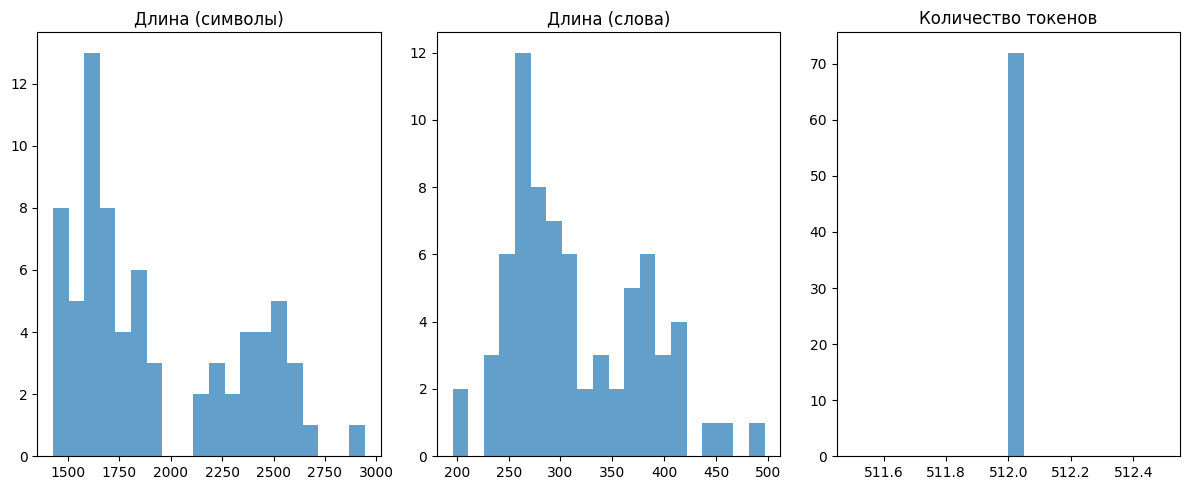

Мин токенов: 512, Макс токенов: 512


In [6]:
# ============================================
# АНАЛИЗ ДЛИН
# ============================================

# Количество токенов берём напрямую из сохранённых ID — всегда 512
token_counts = [len(ids) for ids in all_chunk_ids]

lengths = [len(t) for t in text_chunks]
word_counts = [len(t.split()) for t in text_chunks]

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.hist(lengths, bins=20, alpha=0.7)
plt.title("Длина (символы)")

plt.subplot(1, 3, 2)
plt.hist(word_counts, bins=20, alpha=0.7)
plt.title("Длина (слова)")

plt.subplot(1, 3, 3)
plt.hist(token_counts, bins=20, alpha=0.7)
plt.title("Количество токенов")

plt.tight_layout()
plt.savefig(f"dataset_analysis_variant_{VARIANT}.png")
plt.show()

print(f"Мин токенов: {min(token_counts)}, Макс токенов: {max(token_counts)}")

In [7]:
# ============================================
# СОХРАНЕНИЕ DATASET
# ============================================

dataset_path = f"corpus_variant_{VARIANT}"
raw_dataset.save_to_disk(dataset_path)

dataset_info = {
    "variant": VARIANT,
    "topic": TOPIC,
    "num_samples": len(raw_dataset),
    "total_chars": sum(len(t) for t in text_chunks),
    "model_used": MODEL_NAME,
    "sources": fetched_urls if fetched_urls else SOURCES
}

with open(f"{dataset_path}/info.json", "w", encoding="utf-8") as f:
    json.dump(dataset_info, f, ensure_ascii=False, indent=2)

print(f"Датасет сохранен в папку {dataset_path}")
print(f"Информация: {dataset_info}")

Saving the dataset (1/1 shards): 100%|██████████| 72/72 [00:00<00:00, 3399.79 examples/s]

Датасет сохранен в папку corpus_variant_17
Информация: {'variant': 17, 'topic': 'Sentiment Analysis', 'num_samples': 72, 'total_chars': 139171, 'model_used': 'cointegrated/rubert-tiny-sentiment-balanced', 'sources': ['https://habr.com/ru/companies/otus/articles/724234/', 'https://habr.com/ru/articles/881998/', 'https://en.wikipedia.org/wiki/Sentiment_analysis', 'https://en.wikipedia.org/wiki/Emotion_classification', 'https://huggingface.co/tasks/text-classification']}


In [8]:
# ============================================
# ТЕСТ АНАЛИЗА ТОНАЛЬНОСТИ
# ============================================

test_texts = [
    "Этот сервис очень удобный, всё работает быстро и понятно.",
    "Нормальный продукт, ничего особенного, но пользоваться можно.",
    "Ужасное качество, всё сломалось в первый же день."
]

print("=" * 60)
print(f"ТЕСТ МОДЕЛИ ПО ТЕМЕ: {TOPIC}")
print("=" * 60)

results = []

for text in test_texts:
    result = classifier(text)[0]
    results.append({
        "text": text,
        "label": result["label"],
        "score": float(result["score"])
    })
    print(f"Текст: {text}")
    print(f"Метка: {result['label']}, score={result['score']:.4f}")
    print("-" * 40)

with open(f"{dataset_path}/sentiment_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("Результаты анализа тональности сохранены.")

ТЕСТ МОДЕЛИ ПО ТЕМЕ: Sentiment Analysis
Текст: Этот сервис очень удобный, всё работает быстро и понятно.
Метка: positive, score=0.9883
----------------------------------------
Текст: Нормальный продукт, ничего особенного, но пользоваться можно.
Метка: positive, score=0.6843
----------------------------------------
Текст: Ужасное качество, всё сломалось в первый же день.
Метка: negative, score=0.9814
----------------------------------------
Результаты анализа тональности сохранены.


In [9]:
# ============================================
# СОХРАНЕНИЕ ТЕКСТОВОГО СОДЕРЖИМОГО DATASET
# ============================================

output_file_path = f"{dataset_path}/final_dataset_texts.txt"

with open(output_file_path, "w", encoding="utf-8") as f:
    for i, entry in enumerate(raw_dataset):
        f.write(f"CHUNK {i+1}:\n{entry['text']}\n\n")

print(f"Текстовое содержимое датасета сохранено в файл: {output_file_path}")

Текстовое содержимое датасета сохранено в файл: corpus_variant_17/final_dataset_texts.txt
